# LM TPR Analysis — context-window validity & corrected comparison

Model-side analysis for the discourse-functional (TPR) benchmark. Consumes the human baselines and
distance characterization produced by **human_baseline.ipynb** (no corpus loading here).

A TPR case is a cross-speaker antecedent (prior D×N mention of the topic noun) followed by a target.
A model conditions on the preceding session truncated to its `max_position_embeddings`; a site is
**in-window** iff the antecedent's distance is within that window (`true_dist ≤ context_length`).
We (1) verify the in-window flag against the models' actual inputs, (2) audit how much of each
model's TPR is unseeable, and (3) compare each model to the **window-matched** human references
(children on the same in-window sites; window-constrained other-adults), correcting the distance
mismatch in the raw 0.215 benchmark.

In [1]:
import os, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec, matplotlib.patches as mpatches
from scipy.stats import ttest_rel, ttest_1samp

DISCOURSE_DIR = "output/manchester_discourse_childes"
PASS_ALPHA = 0.05
KEY = ["child_name", "speaker", "sentence_id"]

# --- human artifacts from human_baseline.ipynb ---
ADULT_POP_MEAN = float(pd.read_csv("results/tpr/tpr_human_summary.csv").iloc[0]["adult_tpr_population_mean"])
HWIN = pd.read_csv("results/tpr/human_tpr_by_window.csv")        # window-matched references
def oa_ref_at(W):                                               # pooled other-adult TPR for antecedent within W
    sub = HWIN[HWIN.K <= W]
    return float(sub.iloc[-1].other_adult_pooled_TPR) if len(sub) else float(HWIN.iloc[0].other_adult_pooled_TPR)

# --- TPR case metadata (with true_dist + per-site human switch), from the augmented cache ---
meta = pd.read_csv("output/manchester_tpr_childes/tpr_cached_inputs.csv",
    usecols=["child_name","speaker","sentence_id","noun","previous_det","original_det",
             "previous_sentence","true_dist"])
meta["d_A"] = meta.previous_det.str.lower().map({"a":0,"an":0,"the":1})
meta = meta.dropna(subset=["d_A","true_dist"]); meta["d_A"] = meta.d_A.astype(int)
meta["human_switch"] = ((meta.original_det.str.lower()=="the").astype(int) != meta.d_A).astype(int)

# D×N pass/fail (committed; overlap test, unaffected by truncation)
_ft = pd.read_csv("figures/appendix_full_results_table.csv")
_ft.columns = ["Model","Arch","bias","emp","pred","TPR","DxN","TPRtest","Acc"]
_ft = _ft[~_ft.Model.isin(["Children","Caretakers"])]
DXN = dict(zip(_ft.Model + "|" + _ft.Arch.str.lower().str.replace("s2s","seq2seq"), _ft.DxN.str.contains("checkmark")))
print(f"adult population mean {ADULT_POP_MEAN:.4f} | window refs 1..{int(HWIN.K[HWIN.K<10**8].max())} + all")

adult population mean 0.2155 | window refs 1..200 + all


## 1. Load model predictions and apply the in-window criterion

In [2]:
def _load(md_dir):
    fr = []
    for dd in glob.glob(md_dir + "/*"):
        if not os.path.isdir(dd): continue
        for spk in ["child","mother"]:
            pf = f"{dd}/{spk}_predictions.csv"
            if os.path.exists(pf):
                d = pd.read_csv(pf, usecols=["sentence_id","P_the","P_a","context_length"])
                d["child_name"] = os.path.basename(dd); d["speaker"] = spk; fr.append(d)
    return pd.concat(fr, ignore_index=True) if fr else None

parts = []
for md_dir in sorted(glob.glob(f"{DISCOURSE_DIR}/*/*")):
    if not os.path.isdir(md_dir): continue
    p = _load(md_dir)
    if p is None: continue
    p["model"] = os.path.basename(md_dir); p["arch"] = os.path.basename(os.path.dirname(md_dir))
    parts.append(p)
pred = pd.concat(parts, ignore_index=True)
pred["P_the_B"] = pred.P_the / (pred.P_the + pred.P_a).replace(0, np.nan)
long = pred.merge(meta[KEY + ["d_A","true_dist","human_switch","noun"]], on=KEY, how="inner").dropna(subset=["P_the_B"])
long["contrib"]   = (long.d_A - long.P_the_B).abs()
long["in_window"] = long.true_dist <= long.context_length
print("model×site TPR points:", len(long), "| models:", long.model.nunique(),
      "| overall child in-window:", round(100*long[long.speaker=='child'].in_window.mean(),1), "%")

model×site TPR points: 606326 | models: 47 | overall child in-window: 65.5 %


### Audit: `in_window` matches each model's actual input
Corpus-free check: when `in_window`, the antecedent utterance text is present in the model's
`full_input` (the stronger reconstruction check — corpus "last `context_length` utterances" ==
`full_input` verbatim — was validated to hold 100% across all 49 models in human-baseline prep).

In [3]:
def _nrm(t): return re.sub(r"[^a-z0-9 ]", "", str(t).lower()).strip()
_am = meta[meta.speaker=="child"].set_index(["child_name","sentence_id"])[["previous_sentence","true_dist"]]
rows = []
for md_dir in sorted(glob.glob(f"{DISCOURSE_DIR}/*/*")):
    if not os.path.isdir(md_dir): continue
    model = os.path.basename(md_dir)
    fr = []
    for dd in glob.glob(md_dir + "/*"):
        pf = f"{dd}/child_predictions.csv"
        if os.path.exists(pf):
            d = pd.read_csv(pf, usecols=["sentence_id","full_input","context_length"]); d["child_name"]=os.path.basename(dd); fr.append(d)
    if not fr: continue
    p = pd.concat(fr).merge(_am, left_on=["child_name","sentence_id"], right_index=True, how="inner")
    nin=ain=nout=aout=0
    for r in p.itertuples(index=False):
        ctx = "\n".join(_nrm(l) for l in str(r.full_input).split("\n")[:-1])
        present = _nrm(r.previous_sentence) in ctx
        if r.true_dist <= r.context_length: nin+=1; ain+=present
        else: nout+=1; aout+=present
    rows.append((model, 100*ain/max(nin,1), 100*aout/max(nout,1)))
audit = pd.DataFrame(rows, columns=["model","ante_present_in","ante_present_out"])
assert (audit.ante_present_in > 99.9).all(), "antecedent missing from an in-window input"
print(f"AUDIT PASSED ({len(audit)} models): antecedent present when in_window = 100%% (min {audit.ante_present_in.min():.1f}%%);"
      f" when out-of-window mean {audit.ante_present_out.mean():.2f}%% (short-phrase recurrence)")

AUDIT PASSED (49 models): antecedent present when in_window = 100%% (min 100.0%%); when out-of-window mean 0.12%% (short-phrase recurrence)


## 2. Antecedent-visibility audit (per model)

In [4]:
ch = long[long.speaker=="child"]
vis = (ch.groupby(["model","arch"]).agg(child_sites=("in_window","size"),
        pct_out=("in_window", lambda v: round(100*(~v).mean(),1))).reset_index().sort_values("pct_out", ascending=False))
print("overall child invalid: %.1f%%\n" % (100*(~ch.in_window).mean()))
print(vis.head(6).to_string(index=False)); print("  ..."); print(vis.tail(4).to_string(index=False))

overall child invalid: 34.5%

              model arch  child_sites  pct_out
     baby-llama-58m   ar         5562     50.0
        BabyBERTa-1  mlm         5562     49.6
        BabyBERTa-3  mlm         5562     49.6
        BabyBERTa-2  mlm         5562     49.6
 babyllama-10m-2024   ar         5562     48.5
babyllama-100m-2024   ar         5562     48.4
  ...
                                 model arch  child_sites  pct_out
              babylm-baseline-10m-gpt2   ar         5562     23.8
             babylm-baseline-100m-gpt2   ar         5562     23.8
BabyLM-2026-Baseline-GPT2-Strict-Small   ar         5562     22.6
      BabyLM-2026-Baseline-GPT2-Strict   ar         5562     22.5


## 3. Corrected (in-window) LM-vs-human comparison
The distance-matched counterpart of human_baseline §6: each model on its in-window child sites vs
children's switch rate on the *same* sites (paired across dyads).

In [5]:
def matched(sub):
    g = sub.groupby("child_name").agg(mt=("contrib","mean"), ht=("human_switch","mean")).dropna()
    if len(g) < 2: return (np.nan, np.nan, np.nan)
    return (g.mt.mean(), g.ht.mean(), ttest_rel(g.mt, g.ht)[1])
rows = []
for (model, arch), m in long.groupby(["model","arch"]):
    c = m[m.speaker=="child"]
    am, ah, ap = matched(c); vm, vh, vp = matched(c[c.in_window])
    rows.append(dict(model=model, arch=arch, all_model=am, all_human=ah, all_p=ap, all_pass=ap>PASS_ALPHA,
        win_model=vm, win_human=vh, win_p=vp, win_pass=vp>PASS_ALPHA,
        n_window=int(c.in_window.sum()), dxn=DXN.get(model+"|"+arch)))
matched_df = pd.DataFrame(rows)
matched_df.to_csv("results/tpr/tpr_model_corrected_in_window.csv", index=False)
print("children's mean switch: all sites %.3f -> in-window %.3f" % (matched_df.all_human.mean(), matched_df.win_human.mean()))
print("indistinguishable from children (matched, p>0.05): all-sites %d | in-window %d"
      % (int(matched_df.all_pass.sum()), int(matched_df.win_pass.sum())))
_pb = matched_df[matched_df.win_pass & (matched_df.dxn==True)]
print("PASS BOTH (D×N + matched in-window):", len(_pb), list(_pb.model))

children's mean switch: all sites 0.226 -> in-window 0.169
indistinguishable from children (matched, p>0.05): all-sites 1 | in-window 2
PASS BOTH (D×N + matched in-window): 1 ['roberta-base']


## 4. Corrected full-results table (`appendix_full_results_table_corrected.tex`)
Model rows: in-window TPR (SD over dyads), `n_TPR`, matched test vs children. Human rows: all sites,
one-sample vs the global adult mean (the paper's test). Overlap/bias/D×N/accuracy carried over.

In [6]:
_com = _ft.copy(); _A2L = {"AR":"ar","MLM":"mlm","S2S":"seq2seq"}
_hsum = pd.read_csv("results/tpr/tpr_human_summary.csv").set_index("speaker")
def _fmtp(p): return "<0.001" if p<0.001 else f"{p:.3f}"
def _tc(p, bold=False):
    s = (r"$\checkmark$ ("+_fmtp(p)+")") if p>PASS_ALPHA else (r"$\times$ ("+_fmtp(p)+")")
    return (r"\textbf{"+s+"}") if bold else s
def _fixdxn(s): return s.replace("\\\\", "\\")
_info = {}
for (model, arch), m in long.groupby(["model","arch"]):
    c = m[(m.speaker=="child") & m.in_window]
    g = c.groupby("child_name").agg(mt=("contrib","mean"), ht=("human_switch","mean")).dropna()
    if len(g) >= 2:
        _info[(model,arch)] = dict(tpr=g.mt.mean(), sd=g.mt.std(ddof=1), n=int(len(c)), p=ttest_rel(g.mt,g.ht)[1])
_chp = _hsum.loc["child","p_1sample"]; _mop = _hsum.loc["mother","p_1sample"]
_chn = int((long[long.model==long.model.iloc[0]].speaker=="child").sum())
_mon = int((long[long.model==long.model.iloc[0]].speaker=="mother").sum())
_cap = (r"\textbf{Corrected, context-aware TPR.} Model TPR (SD) and $n_\text{TPR}$ are computed only on "
        r"sites whose antecedent lies within the model's context window; the TPR test is a paired comparison "
        r"vs children on those same in-window sites. Human rows use all utterances and the one-sample test "
        r"vs the global adult mean. Bias, overlap, D$\times$N and accuracy are unchanged.")
_L = [r"\begin{table*}[]", rf"\caption{{{_cap}}}", r"\label{tab:full-results-corrected}",
      r"\begin{adjustbox}{max width=\textwidth}", r"\begin{tabular}{llccccccccc}", r"\toprule",
      r"Model & Arch. & \texttt{bias} & \texttt{empirical} (SD) & \texttt{predicted} (SD) & TPR (SD) & $n_\text{TPR}$ & \texttt{D$\times$N} test & TPR test & Accuracy \\",
      r"\midrule",
      rf"Children & Human & 0.834 & 0.260 (0.067) & 0.249 (0.112) & 0.226 (0.050) & {_chn} & \textbf{{$\checkmark$ (0.539)}} & {_tc(_chp, True)} & -- \\",
      rf"Caretakers & Human & 0.815 & 0.309 (0.041) & 0.329 (0.071) & 0.200 (0.046) & {_mon} & \textbf{{$\checkmark$ (0.222)}} & {_tc(_mop, True)} & -- \\",
      r"\midrule"]
for _, r in _com.iterrows():
    v = _info.get((r.Model, _A2L.get(r.Arch.strip())))
    if v is None: continue
    _L.append(f"{r.Model.replace('_', chr(92)+'_')} & {r.Arch.strip()} & {r.bias} & {r.emp} & {r.pred} & "
              f"{v['tpr']:.3f} ({v['sd']:.3f}) & {v['n']} & {_fixdxn(r.DxN)} & {_tc(v['p'])} & {r.Acc} \\\\")
_L += [r"\bottomrule", r"\end{tabular}", r"\end{adjustbox}", r"\end{table*}"]
open("figures/appendix_full_results_table_corrected.tex","w").write("\n".join(_L))
print(f"saved figures/appendix_full_results_table_corrected.tex ({len(_info)} model rows)")

saved figures/appendix_full_results_table_corrected.tex (49 model rows)


## 5. Corrected TPR by context-window tier
Faceted by the (nested) window tiers. Blue dotted = children's in-window TPR avg (blue shading =
passes paired vs children); green dashed = **window-constrained** other-adult TPR avg from
`human_tpr_by_window.csv` (green shading = passes one-sample vs constrained other-adults).

/tmp/claude-501/ipykernel_38792/1438340586.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.955))


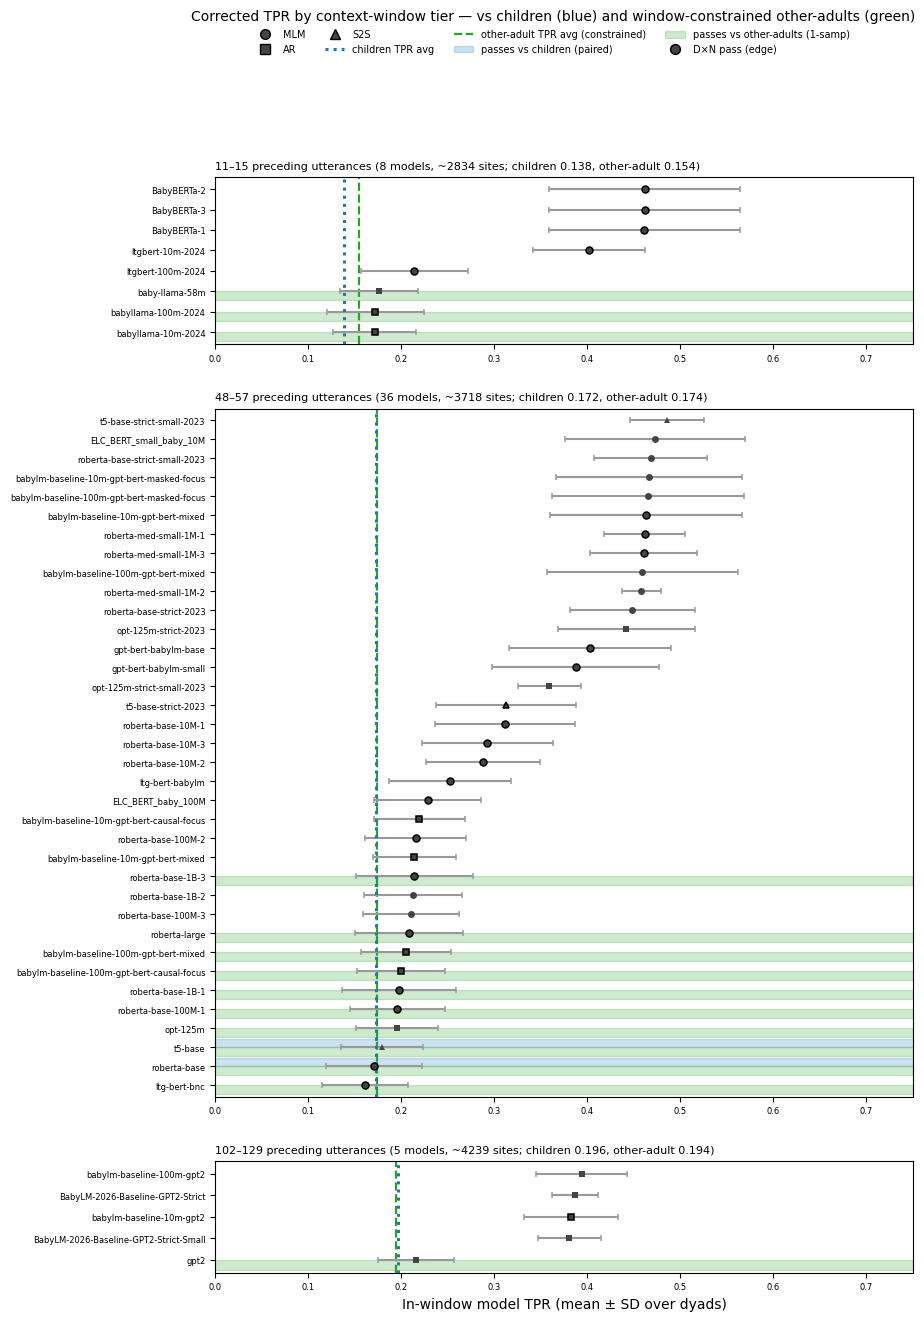

pass vs children: {'medium': np.int64(2)} | pass vs other-adults: {'large': np.int64(1), 'medium': np.int64(10), 'small': np.int64(3)}


In [7]:
_recs = []
for (model, arch), m in long.groupby(["model","arch"]):
    c = m[(m.speaker=="child") & m.in_window]
    g = c.groupby("child_name").agg(mt=("contrib","mean"), ht=("human_switch","mean")).dropna()
    if len(g) < 2: continue
    W = int(m[m.speaker=="child"].context_length.median()); oref = oa_ref_at(W)
    _recs.append(dict(model=model, arch=arch, tpr=g.mt.mean(), sd=g.mt.std(ddof=1), n_tpr=int(len(c)),
        win_human=g.ht.mean(), child_p=ttest_rel(g.mt, g.ht)[1], oa_ref=oref, oa_p=ttest_1samp(g.mt, oref)[1],
        med_ctx=W, dxn=bool(DXN.get(model+"|"+arch))))
fig_df = pd.DataFrame(_recs)
fig_df["child_pass"] = fig_df.child_p > PASS_ALPHA; fig_df["oa_pass"] = fig_df.oa_p > PASS_ALPHA
fig_df["tier"] = fig_df.med_ctx.map(lambda w: "small" if w<20 else ("medium" if w<80 else "large"))
BLUE, GREEN = "#1f77b4", "#2ca02c"; arch_shape = {"ar":"s","mlm":"o","seq2seq":"^"}
tiers = ["small","medium","large"]; cnt = {t:int((fig_df.tier==t).sum()) for t in tiers}
fig = plt.figure(figsize=(9, 0.27*len(fig_df)+1.0))
gs = gridspec.GridSpec(3, 1, height_ratios=[cnt[t]+1.0 for t in tiers], hspace=0.20)
for gi, tier in enumerate(tiers):
    ax = fig.add_subplot(gs[gi]); sub = fig_df[fig_df.tier==tier].sort_values("tpr").reset_index(drop=True)
    cl, ol = sub.win_human.mean(), sub.oa_ref.mean()
    for y, r in sub.iterrows():
        if r.child_pass: ax.axhspan(y, y+0.45, color=BLUE, alpha=0.22, zorder=0)
        if r.oa_pass:    ax.axhspan(y-0.45, y, color=GREEN, alpha=0.22, zorder=0)
        ax.errorbar(r.tpr, y, xerr=r.sd, fmt=arch_shape.get(r.arch,"o"), color="#444", ecolor="#999",
                    capsize=2, ms=5, markeredgecolor=("black" if r.dxn else "none"), markeredgewidth=1.1, zorder=3)
    ax.axvline(cl, color=BLUE, ls=":", lw=2.2, zorder=3); ax.axvline(ol, color=GREEN, ls="--", lw=1.6, zorder=2)
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.model, fontsize=6)
    ax.set_ylim(-0.6, len(sub)-0.4); ax.set_xlim(0, 0.75); ax.tick_params(labelsize=6)
    ax.set_title(f"{int(sub.med_ctx.min())}–{int(sub.med_ctx.max())} preceding utterances "
                 f"({len(sub)} models, ~{int(sub.n_tpr.median())} sites; children {cl:.3f}, other-adult {ol:.3f})", fontsize=8, loc="left")
    if gi==2: ax.set_xlabel("In-window model TPR (mean ± SD over dyads)")
handles = [Line2D([0],[0],marker=arch_shape[a],color="w",markerfacecolor="#444",markeredgecolor="k",label=l,ms=7)
           for a,l in [("mlm","MLM"),("ar","AR"),("seq2seq","S2S")]]
handles += [Line2D([0],[0],color=BLUE,ls=":",lw=2.2,label="children TPR avg"),
            Line2D([0],[0],color=GREEN,ls="--",lw=1.6,label="other-adult TPR avg (constrained)"),
            mpatches.Patch(color=BLUE,alpha=0.22,label="passes vs children (paired)"),
            mpatches.Patch(color=GREEN,alpha=0.22,label="passes vs other-adults (1-samp)"),
            Line2D([0],[0],marker="o",color="w",markerfacecolor="#444",markeredgecolor="k",markeredgewidth=1.1,label="D×N pass (edge)",ms=7)]
fig.tight_layout(rect=(0, 0, 1, 0.955))
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.96), ncol=4, fontsize=7, frameon=False)
fig.suptitle("Corrected TPR by context-window tier — vs children (blue) and window-constrained other-adults (green)", y=0.998, fontsize=10)
fig.savefig("figures/appendix_full_tpr_figure_corrected.png", dpi=200, bbox_inches="tight"); plt.show()
print("pass vs children:", dict(fig_df[fig_df.child_pass].groupby("tier").size()),
      "| pass vs other-adults:", dict(fig_df[fig_df.oa_pass].groupby("tier").size()))

## 6. Analytical TPR — four-test model summary

The canonical per-model TPR test table consumed by `analysis.ipynb`. Uses the **analytical** TPR
values (`analytical_tpr_all_results.csv`, from `compute_analytical_metrics.py`) — computed directly
from the stored probability distributions, so fully deterministic — and the per-dyad human reference
distributions exported by `human_baseline.ipynb` (`tpr_human_perdyad_references.csv`).

Four tests per model (all on the unrestricted noun set, child-speaker rows):
1. One-sample t-test vs. the pooled other-adult population mean
2. Welch independent t-test vs. the other-adult dyad TPRs
3. Paired t-test vs. Manchester children
4. Paired t-test vs. Manchester caretakers

Output: `results/tpr/tpr_model_summary_analytical.csv`

In [8]:
from scipy.stats import ttest_ind

# Per-dyad human references + pooled adult mean (from human_baseline.ipynb)
_refs = pd.read_csv("results/tpr/tpr_human_perdyad_references.csv")
oa_tprs            = _refs[_refs.speaker == "other_adult"]["tpr_unrestricted"].dropna()
oa_population_mean = float(pd.read_csv("results/tpr/tpr_human_summary.csv").iloc[0]["adult_tpr_population_mean"])
old_child_ref  = (_refs[_refs.speaker == "child"][["child_name_norm", "tpr_unrestricted"]]
                  .rename(columns={"tpr_unrestricted": "old_tpr_unrestricted"}).dropna())
old_mother_ref = (_refs[_refs.speaker == "mother"][["child_name_norm", "tpr_unrestricted"]]
                  .rename(columns={"tpr_unrestricted": "old_tpr_unrestricted"}).dropna())

analytical_tpr_all = pd.read_csv("results/tpr/analytical_tpr_all_results.csv")
print(f"Loaded analytical TPR: {len(analytical_tpr_all):,} rows, {analytical_tpr_all['model_name'].nunique()} models")
analytical_child = analytical_tpr_all[analytical_tpr_all["speaker"] == "child"].copy()
analytical_child["child_name_norm"] = (
    analytical_child["child_name"].astype(str).str.lower().str.replace("warr", "warren", regex=False))

rows_analytical = []
for (model_name, model_type), g in analytical_child.groupby(["model_name", "model_type"], sort=True):
    vals = g["tpr_overall"].dropna()
    if len(vals) < 2:
        continue
    t_welch, p_welch = ttest_ind(vals, oa_tprs, equal_var=False)
    t_1samp, p_1samp = ttest_1samp(vals, oa_population_mean)
    g_pair = g[["child_name", "tpr_overall", "child_name_norm"]].copy()
    paired_child  = g_pair.merge(old_child_ref,  on="child_name_norm", how="inner")
    n_paired_c    = len(paired_child)
    t_rel_c, p_rel_c = (ttest_rel(paired_child["tpr_overall"], paired_child["old_tpr_unrestricted"])
                        if n_paired_c >= 2 else (np.nan, np.nan))
    paired_mother = g_pair.merge(old_mother_ref, on="child_name_norm", how="inner")
    n_paired_m    = len(paired_mother)
    t_rel_m, p_rel_m = (ttest_rel(paired_mother["tpr_overall"], paired_mother["old_tpr_unrestricted"])
                        if n_paired_m >= 2 else (np.nan, np.nan))
    rows_analytical.append({
        "model_name": model_name, "model_short": str(model_name).split("/")[-1], "model_type": model_type,
        "n_model_dyads": int(len(vals)), "mean_model_tpr": float(vals.mean()), "sd_model_tpr": float(vals.std(ddof=1)),
        "n_paired_child_dyads": n_paired_c, "n_paired_mother_dyads": n_paired_m,
        "mean_other_adult_tpr": float(oa_tprs.mean()), "other_adult_population_mean": float(oa_population_mean),
        "onesample_t": float(t_1samp), "onesample_p": float(p_1samp),
        "welch_t": float(t_welch), "welch_p": float(p_welch),
        "paired_vs_child_t":  float(t_rel_c) if pd.notna(t_rel_c) else np.nan,
        "paired_vs_child_p":  float(p_rel_c) if pd.notna(p_rel_c) else np.nan,
        "paired_vs_mother_t": float(t_rel_m) if pd.notna(t_rel_m) else np.nan,
        "paired_vs_mother_p": float(p_rel_m) if pd.notna(p_rel_m) else np.nan,
    })

analytical_model_summary = pd.DataFrame(rows_analytical).rename(columns={
    "onesample_p": "p_1sample", "welch_p": "p_welch_vs_adults",
    "paired_vs_child_p": "p_paired_child", "paired_vs_mother_p": "p_paired_mother"})
analytical_model_summary.to_csv("results/tpr/tpr_model_summary_analytical.csv", index=False)
print(f"Saved: results/tpr/tpr_model_summary_analytical.csv  ({len(analytical_model_summary)} models)")

_pass = ((analytical_model_summary["p_1sample"]         >= PASS_ALPHA) &
         (analytical_model_summary["p_welch_vs_adults"] >= PASS_ALPHA) &
         (analytical_model_summary["p_paired_child"]    >= PASS_ALPHA) &
         (analytical_model_summary["p_paired_mother"]   >= PASS_ALPHA))
print(f"Models passing all four TPR tests (uncorrected, all sites): {int(_pass.sum())} / {len(analytical_model_summary)}")
print(analytical_model_summary.loc[_pass, ["model_short", "mean_model_tpr", "p_1sample",
      "p_welch_vs_adults", "p_paired_child", "p_paired_mother"]].round(4).to_string(index=False))

Loaded analytical TPR: 1,176 rows, 47 models
Saved: results/tpr/tpr_model_summary_analytical.csv  (49 models)
Models passing all four TPR tests (uncorrected, all sites): 1 / 49
 model_short  mean_model_tpr  p_1sample  p_welch_vs_adults  p_paired_child  p_paired_mother
ltg-bert-bnc           0.225     0.5046              0.774          0.8612           0.0592


## 7. Model TPR vs context window $K$, faceted by model family

The per-model analogue of the human TPR-vs-$K$ curve (human_baseline §6): for each model, TPR
(mean $|d_A - P_\text{the}|$) over its child sites whose antecedent lies within $K$ utterances,
swept up to the model's own context window — so a curve never includes sites where the antecedent
was unseeable. Facets and family groupings mirror `appendix_full_overlap_models_figure.png`; the two
human *overlap* facets become reference overlays instead. **Children** (the benchmark's paired
reference) is drawn as a solid line in every facet; the caretaker–other-adult spread is shown as a
faint shaded human band. Output: `figures/appendix_full_tpr_vs_window_models_figure.png`.

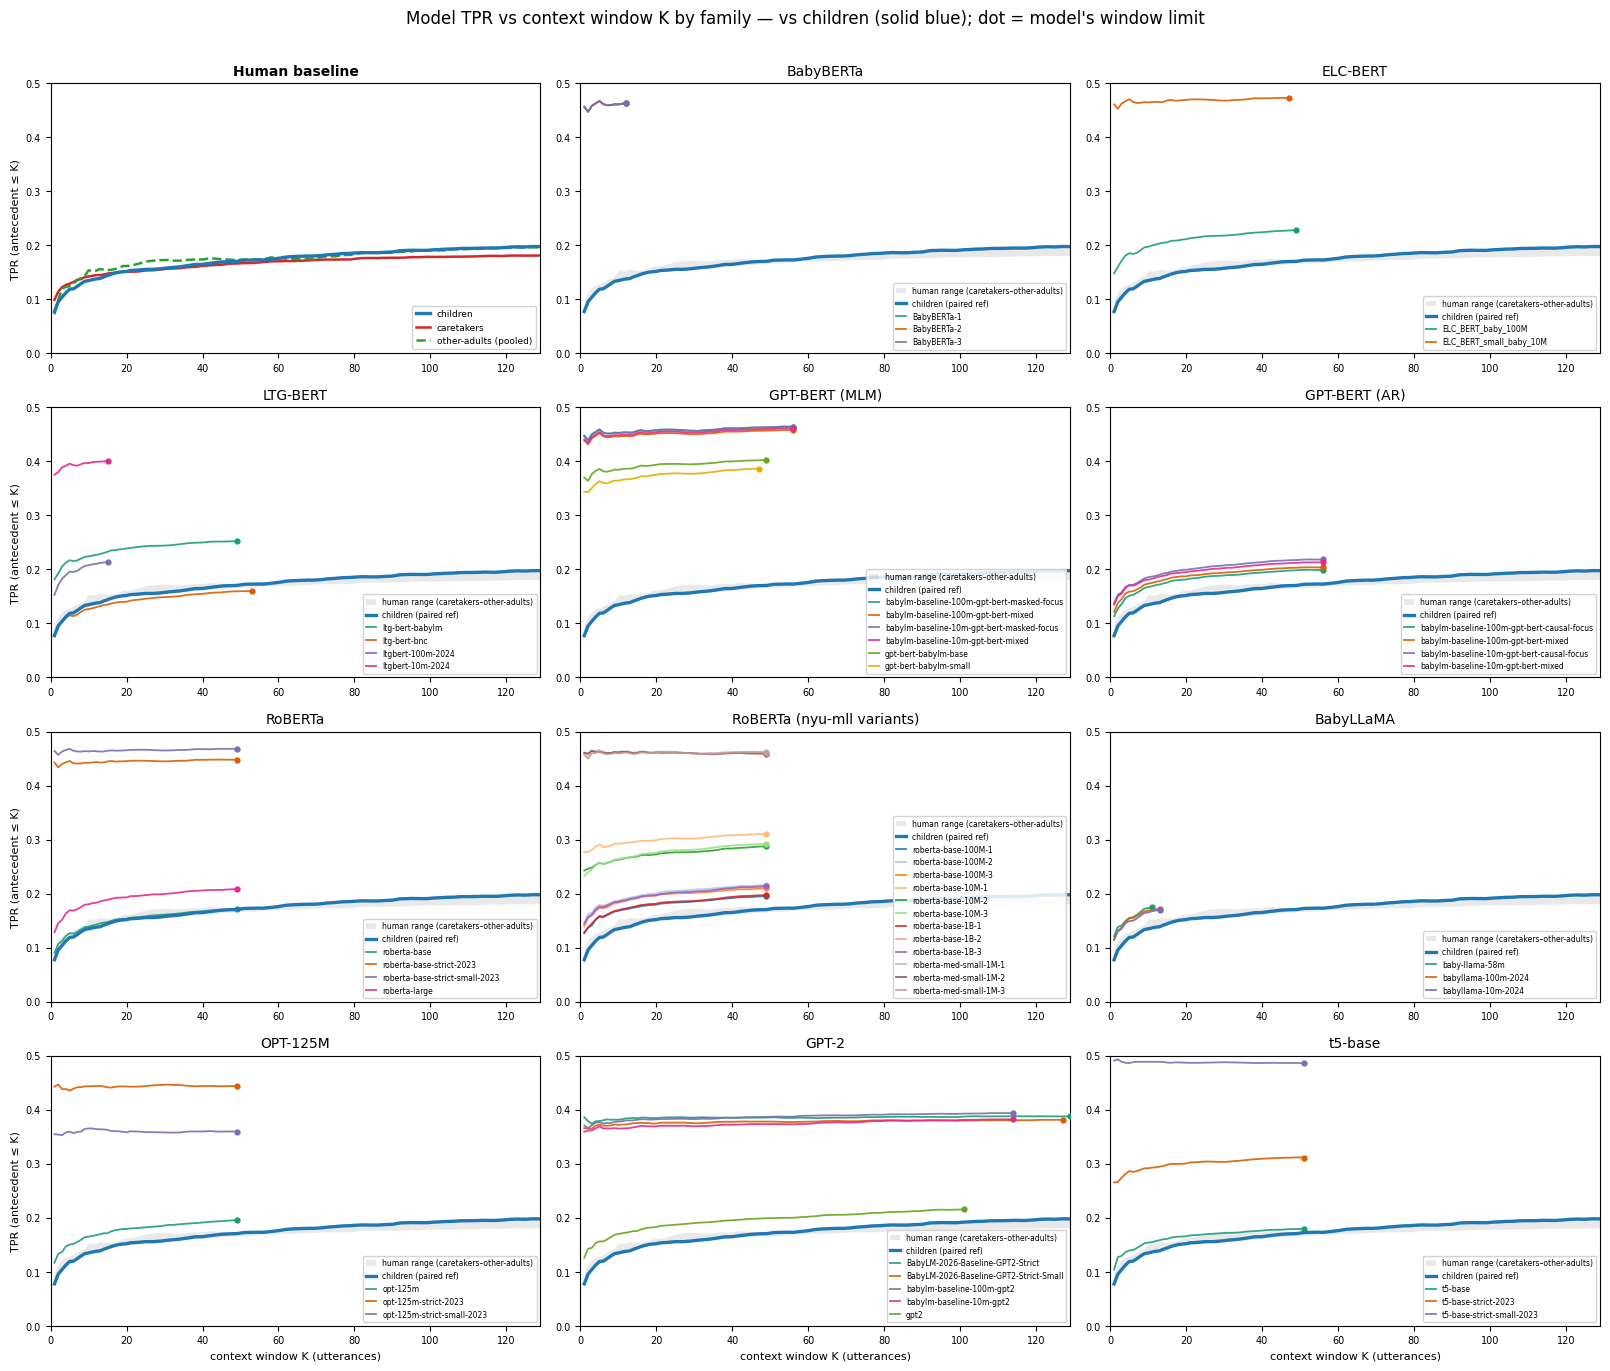

saved figures/appendix_full_tpr_vs_window_models_figure.png  (1 human + 11 family facets = 12, KMAX=129)
children asymptote 0.198 | caretakers 0.181 | other-adult 0.196


In [9]:
# --- family assignment (mirrors analysis.ipynb OVERLAP_FAMILY_RULES) ---
OVERLAP_FAMILY_RULES = {
    ("gpt2", "babylm-baseline"): "GPT-2", "babyberta": "BabyBERTa",
    "elc_bert": "ELC-BERT", "elc-bert": "ELC-BERT", "ltg-bert": "LTG-BERT", "ltgbert": "LTG-BERT",
    "gpt-bert-babylm": "GPT-BERT (MLM)",
    "babylm-baseline-10m-gpt-bert":  {"ar": "GPT-BERT (AR)", "mlm": "GPT-BERT (MLM)"},
    "babylm-baseline-100m-gpt-bert": {"ar": "GPT-BERT (AR)", "mlm": "GPT-BERT (MLM)"},
    "roberta-base-strict": "RoBERTa", "roberta-med-small": "RoBERTa (nyu-mll variants)",
    "roberta-base-": "RoBERTa (nyu-mll variants)", "roberta-base": "RoBERTa", "roberta-large": "RoBERTa",
    "babyllama": "BabyLLaMA", "baby-llama": "BabyLLaMA",
    "opt-125m-strict": "OPT-125M", "opt-125m": "OPT-125M", "opt": "OPT-125M",
    "gpt2": "GPT-2", "t5-base-strict": "t5-base", "t5": "t5-base",
}
OVERLAP_FAMILY_FALLBACK = {"mlm": "Other MLM", "ar": "Other AR", "s2s": "Other S2S", "seq2seq": "Other S2S"}
FAMILY_ORDER = ["BabyBERTa", "ELC-BERT", "LTG-BERT", "GPT-BERT (MLM)", "GPT-BERT (AR)",
                "RoBERTa", "RoBERTa (nyu-mll variants)", "BabyLLaMA", "OPT-125M", "GPT-2",
                "t5-base", "Other MLM", "Other AR", "Other S2S"]
def _family(model, arch):
    name = str(model).lower()
    for key, val in OVERLAP_FAMILY_RULES.items():
        hit = all(k in name for k in key) if isinstance(key, tuple) else key in name
        if hit:
            return val.get(str(arch).lower(), val.get("default", "Other")) if isinstance(val, dict) else val
    return OVERLAP_FAMILY_FALLBACK.get(str(arch).lower(), "Other")

lc = long[long.speaker == "child"].copy()
lc["family"] = [_family(m, a) for m, a in zip(lc.model, lc.arch)]
ctx = lc.groupby(["model", "arch"]).context_length.median().astype(int)
KMAX = int(ctx.max())
Ks = np.unique(np.concatenate([np.arange(1, 21), np.linspace(20, KMAX, 60).astype(int)]))

# --- per-model in-window TPR(antecedent <= K), capped at the model's own window ---
def _model_curve(sub, W):
    s_in = sub[sub.in_window]
    ys = []
    for k in Ks:
        if k > W:
            ys.append(np.nan); continue
        s = s_in[s_in.true_dist <= k]
        ys.append(s.groupby('child_name').contrib.mean().mean() if len(s) else np.nan)
    return np.array(ys)

# --- corpus-free human references at each K ---
def _human_curve(spk):
    m = meta[meta.speaker == spk]
    return np.array([m[m.true_dist <= k].groupby('child_name').human_switch.mean().mean() for k in Ks])
children_K   = _human_curve('child')
caretakers_K = _human_curve('mother')
HWIN_s = HWIN.sort_values('K')
otheradult_K = np.array([float(HWIN_s[HWIN_s.K <= k].iloc[-1].other_adult_pooled_TPR)
                         if (HWIN_s.K <= k).any() else np.nan for k in Ks])
band_lo = np.nanmin(np.vstack([children_K, caretakers_K, otheradult_K]), axis=0)
band_hi = np.nanmax(np.vstack([children_K, caretakers_K, otheradult_K]), axis=0)
CHILD_BLUE = "#1f77b4"

present = lc.family.dropna().unique().tolist()
model_facets = [f for f in FAMILY_ORDER if f in present] + sorted(f for f in present if f not in FAMILY_ORDER)
facets = ["Human baseline"] + model_facets  # reference panel first -> 12 facets (4x3)
ncols = 3; nrows = int(np.ceil(len(facets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 3.4 * nrows), squeeze=False)
axes_flat = axes.flatten()
for idx, fam in enumerate(facets):
    ax = axes_flat[idx]
    if fam == "Human baseline":
        ax.plot(Ks, children_K,   color="#1f77b4", lw=2.4, zorder=4, label="children")
        ax.plot(Ks, caretakers_K, color="#d62728", lw=1.8, zorder=3, label="caretakers")
        ax.plot(Ks, otheradult_K, color="#2ca02c", lw=1.8, ls="--", zorder=3, label="other-adults (pooled)")
        ax.set_xlim(0, KMAX); ax.set_ylim(0, max(0.5, np.nanmax(band_hi) * 1.15))
        ax.set_title("Human baseline", fontsize=10, fontweight="bold")
        ax.tick_params(labelsize=7); ax.set_ylabel("TPR (antecedent \u2264 K)", fontsize=8)
        ax.legend(fontsize=6.5, loc="lower right", framealpha=0.85, handlelength=1.5)
        continue
    ax.fill_between(Ks, band_lo, band_hi, color="#888888", alpha=0.18, lw=0, zorder=0,
                    label="human range (caretakers\u2013other-adults)")
    ax.plot(Ks, children_K, color=CHILD_BLUE, lw=2.4, zorder=4, label="children (paired ref)")
    sub_fam = lc[lc.family == fam]
    models = sorted(sub_fam.model.unique())
    cmap = plt.get_cmap("Dark2" if len(models) <= 8 else "tab20")  # avoid children-blue collision
    for mi, model in enumerate(models):
        for arch, g in sub_fam[sub_fam.model == model].groupby("arch"):
            W = int(ctx.loc[(model, arch)])
            y = _model_curve(g, W)
            ax.plot(Ks, y, color=cmap(mi % cmap.N), lw=1.3, alpha=0.9, zorder=3,
                    label=(model if len(list(sub_fam[sub_fam.model==model].arch.unique()))==1 else f"{model} ({arch})"))
            j = np.where(~np.isnan(y))[0]
            if len(j):
                ax.plot(Ks[j[-1]], y[j[-1]], marker="o", ms=3.5, color=cmap(mi % cmap.N), zorder=3)
    ax.set_xlim(0, KMAX); ax.set_ylim(0, max(0.5, np.nanmax(band_hi) * 1.15))
    ax.set_title(fam, fontsize=10)
    ax.tick_params(labelsize=7)
    if idx % ncols == 0: ax.set_ylabel("TPR (antecedent \u2264 K)", fontsize=8)
    if idx // ncols == nrows - 1: ax.set_xlabel("context window K (utterances)", fontsize=8)
    ax.legend(fontsize=5.5, loc="lower right", framealpha=0.85, handlelength=1.3)
for j in range(len(facets), len(axes_flat)):
    axes_flat[j].axis("off")
fig.suptitle("Model TPR vs context window K by family \u2014 vs children (solid blue); dot = model's window limit",
             y=1.005, fontsize=12)
fig.tight_layout()
fig.savefig("figures/appendix_full_tpr_vs_window_models_figure.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"saved figures/appendix_full_tpr_vs_window_models_figure.png  (1 human + {len(model_facets)} family facets = {len(facets)}, KMAX={KMAX})")
print("children asymptote %.3f | caretakers %.3f | other-adult %.3f"
      % (children_K[-1], caretakers_K[-1], otheradult_K[-1]))